# 2. REVENUE FORECASTING (HOLT-WINTERS EXPONENTIAL SMOOTHING)
**Objective:** Generate macro (company-wide) and granular (sub-category level) time-series revenue forecasts for Q1 2026. This model utilizes the Holt-Winters method to account for both trend and seasonality in the RheinTrade ERP dataset.

In [14]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import pyodbc 
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = 'white'
print("Forecasting & Visualization libraries successfully imported.")

Forecasting & Visualization libraries successfully imported.


### 2.1. Establishing Database Connection & Advanced Revenue Extraction
We use an advanced SQL query that mimics the Power BI `Total Revenue` measure. It filters for 'Delivered', 'Partially Returned', and 'Returned' orders while subtracting `RefundAmount` from gross sales to ensure the forecast is based on **Net Revenue**.

In [15]:
# 2. DATABASE CONNECTION & DATA EXTRACTION
server = 'DESKTOP-O8PCC7J\\SQLEXPRESS03' 
database = 'RheinTrade Solutions'
conn_str = (
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    rf'SERVER={server};'
    rf'DATABASE={database};'
    r'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    
    # Query designed to align with Power BI [Total Revenue] measure
    query = """
    WITH BaseOrderData AS (
        SELECT 
            o.OrderID, o.OrderDate, od.OrderDetailID, od.ProductID,
            cat.CategoryName AS SubCategory, pcat.CategoryName AS ParentCategory,
            p.ProductStatus, od.Quantity, od.UnitPrice, od.DiscountRate
        FROM Orders o
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products p ON od.ProductID = p.ProductID
        JOIN Categories cat ON p.CategoryID = cat.CategoryID
        LEFT JOIN Categories pcat ON cat.ParentCategoryID = pcat.CategoryID
        WHERE o.OrderStatus IN ('Delivered', 'Partially Returned', 'Returned')
    ),
    AggregatedReturns AS (
        SELECT OrderDetailID, SUM(RefundAmount) AS TotalRefundAmount
        FROM Returns
        GROUP BY OrderDetailID
    )
    SELECT 
        b.OrderDate, b.ParentCategory, b.SubCategory, b.ProductStatus,
        ((b.Quantity * b.UnitPrice * (1 - b.DiscountRate)) - ISNULL(r.TotalRefundAmount, 0)) AS NetRevenue
    FROM BaseOrderData b
    LEFT JOIN AggregatedReturns r ON b.OrderDetailID = r.OrderDetailID
    """
    
    df_raw = pd.read_sql(query, conn)
    print(f"Data extraction complete. Total rows retrieved: {df_raw.shape[0]}")
except pyodbc.Error as e:
    print("Database connection failed:", e)
finally:
    if 'conn' in locals():
        conn.close()

Data extraction complete. Total rows retrieved: 1735


### 2.2. Data Truncation & Preparation
To prevent incomplete Q1 2026 data from skewing the model, we truncate the dataset at `2025-12-31`. We also filter out discontinued products to focus the forecast on active business lines.

In [16]:
# 3. DATA CLEANING & TRUNCATION
df_active = df_raw[df_raw['ProductStatus'] != 'Discontinued'].copy()
df_active['OrderDate'] = pd.to_datetime(df_active['OrderDate'])

# Truncate at year-end 2025 to ensure clean training data
df_clean = df_active[df_active['OrderDate'] <= '2025-12-31']

print(f"Dataset truncated at 2025-12-31. Ready for time-series analysis.")

Dataset truncated at 2025-12-31. Ready for time-series analysis.


### 3. Stage 3: Macro Forecasting (Company-Wide Baseline)
We first establish a macro-level forecast for the entire portfolio to understand the general Q1 2026 revenue trajectory.

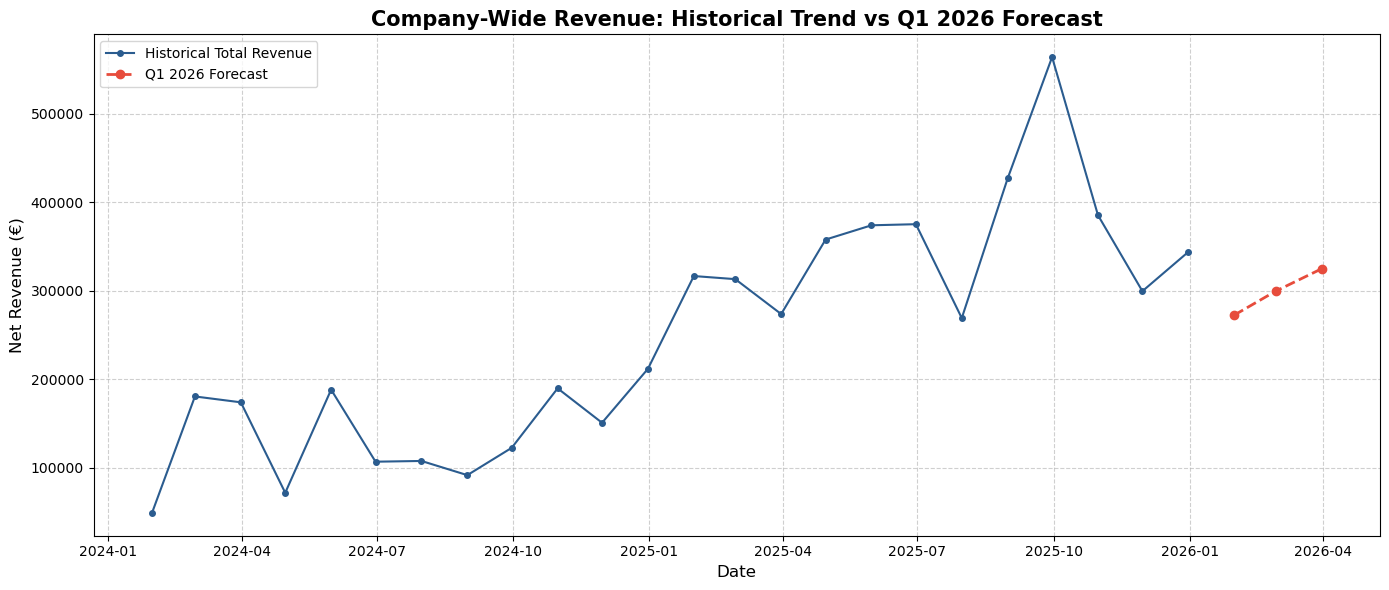

--- MACRO LEVEL REVENUE FORECAST (Q1 2026) ---


2026-01-31    272453
2026-02-28    299531
2026-03-31    324821
Freq: ME, dtype: int64

In [17]:
# 4. MACRO LEVEL FORECASTING & VISUALIZATION
ts_total = df_clean.groupby(pd.Grouper(key='OrderDate', freq='ME'))['NetRevenue'].sum().reset_index()
ts_total.set_index('OrderDate', inplace=True)
ts_total.index.freq = 'ME'

model_total = ExponentialSmoothing(
    ts_total['NetRevenue'], trend='add', seasonal='add', seasonal_periods=12, initialization_method='estimated'
).fit()

forecast_total = model_total.forecast(3)

# --- VISUALIZATION: MACRO LEVEL ---
plt.figure(figsize=(14, 6))

# Historical data 
hist_plot = ts_total[ts_total.index >= '2024-01-01']
plt.plot(hist_plot.index, hist_plot['NetRevenue'], color='#2b5c8f', marker='o', markersize=4, label='Historical Total Revenue')

# Forecast data
plt.plot(forecast_total.index, forecast_total.values, color='#e74c3c', marker='o', markersize=6, linestyle='--', linewidth=2, label='Q1 2026 Forecast')

plt.title('Company-Wide Revenue: Historical Trend vs Q1 2026 Forecast', fontsize=15, fontweight='bold')
plt.ylabel('Net Revenue (€)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("--- MACRO LEVEL REVENUE FORECAST (Q1 2026) ---")
display(forecast_total.round(0).astype(int))

### 4. Stage 3.1: Granular Forecasting (Comprehensive Sub-Category Level)
Moving beyond the macro view, we generate individual forecasts for every sub-category. This allows for operational planning and targeted inventory management.

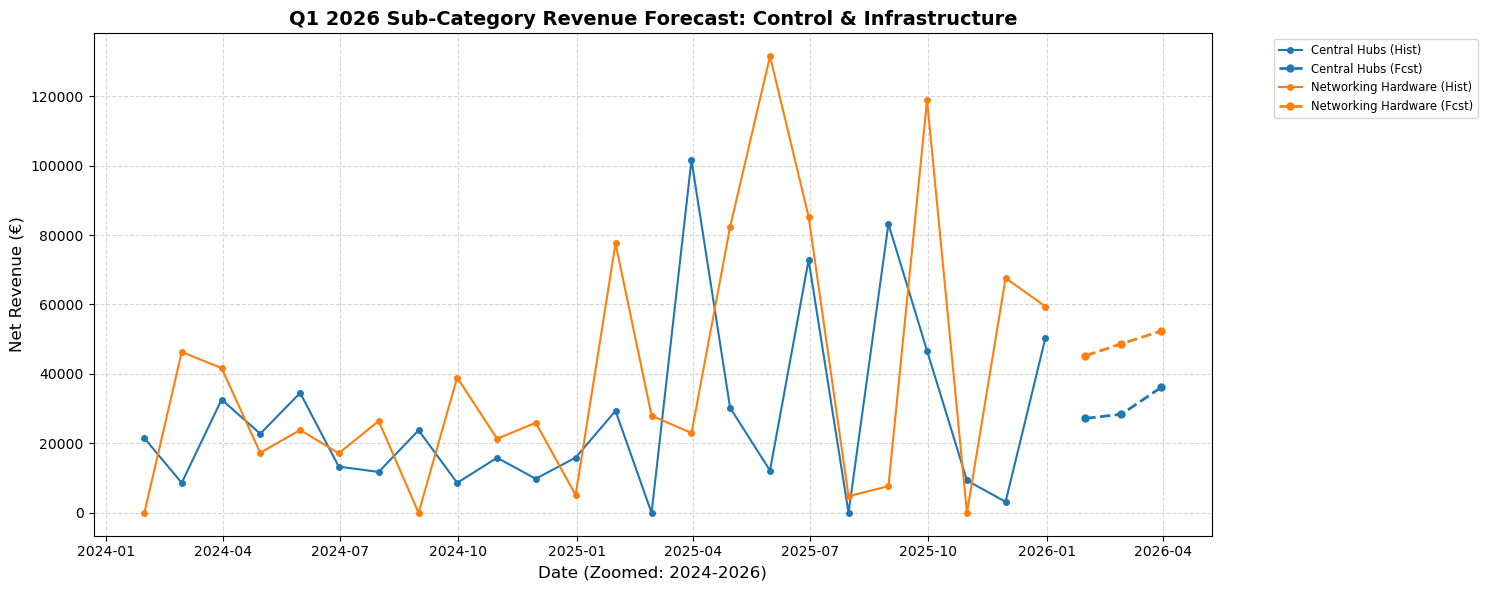

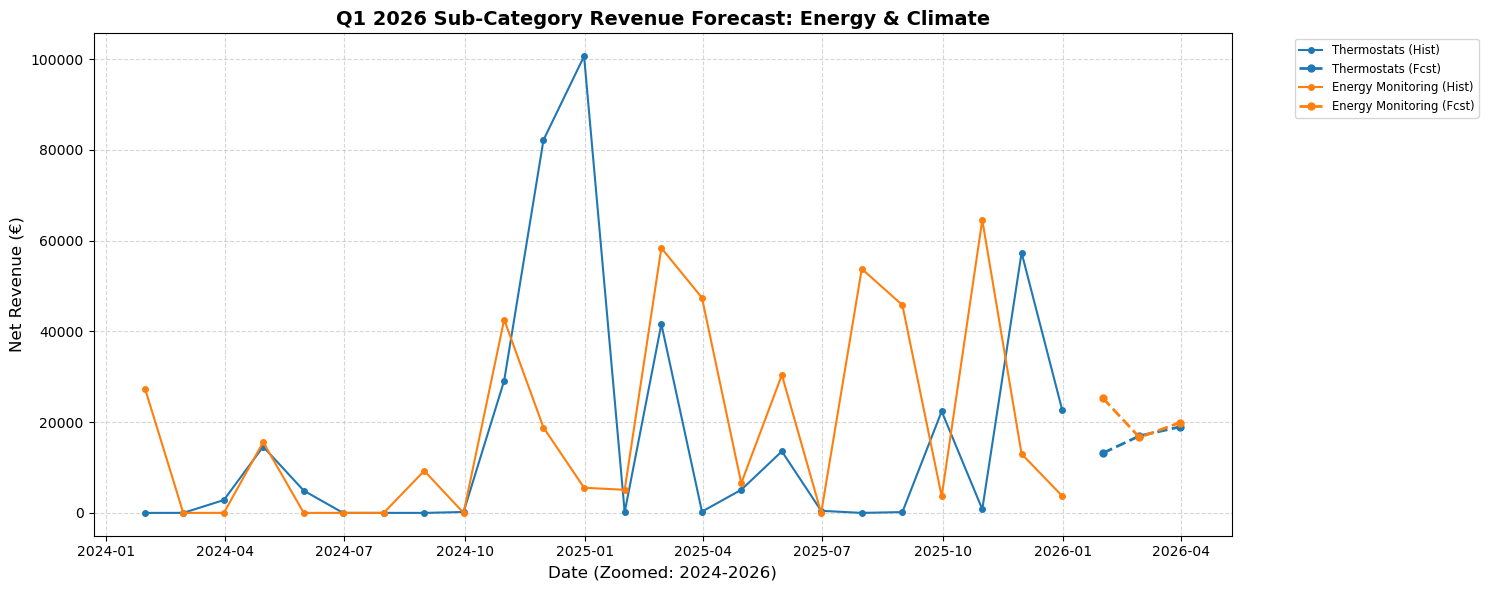

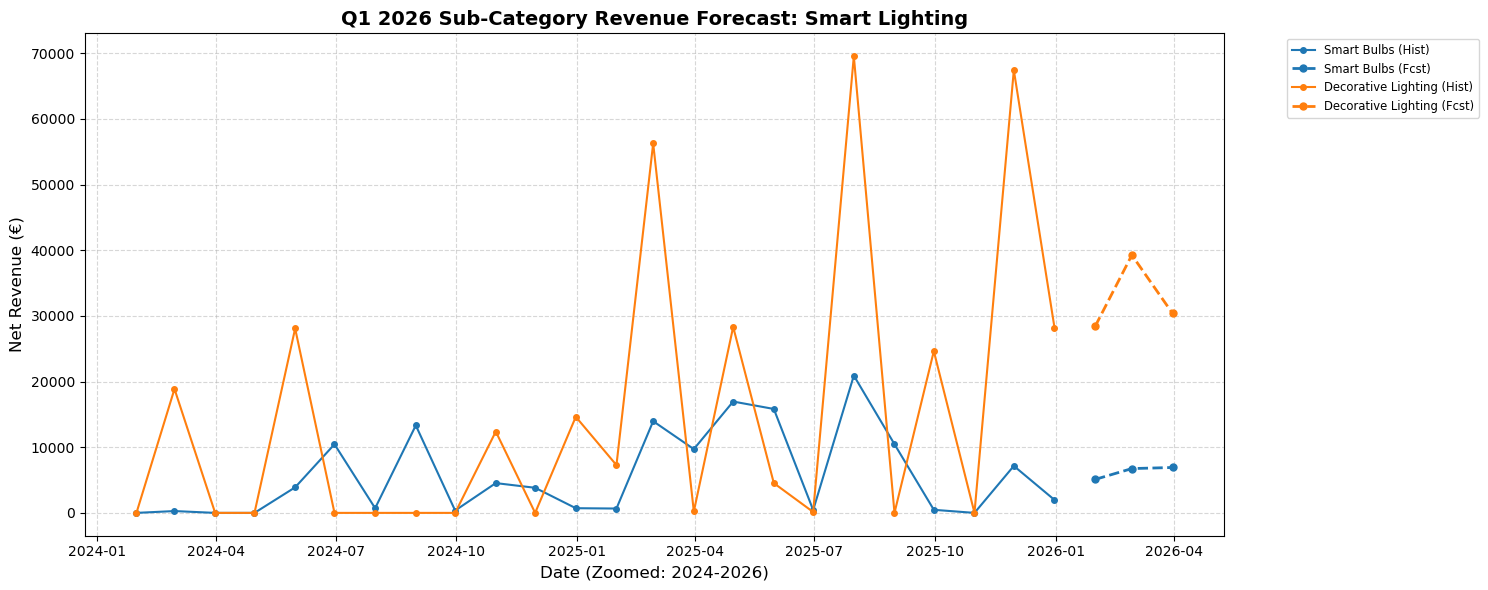

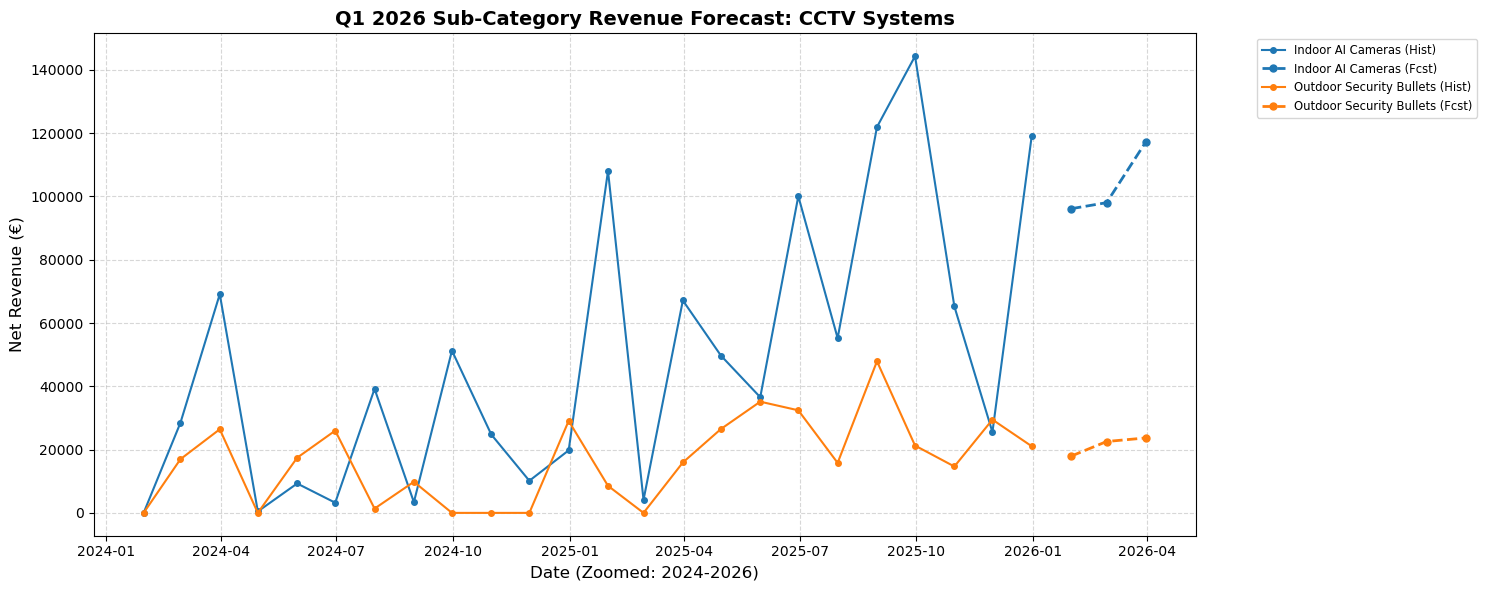

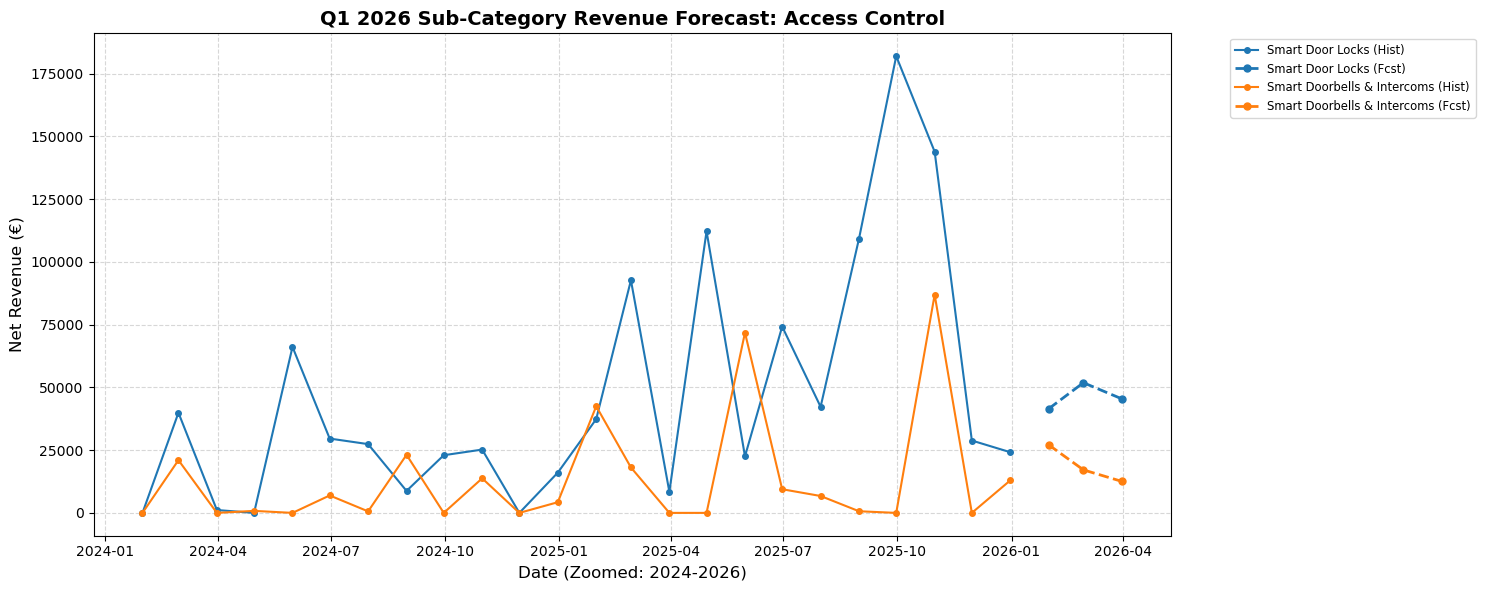


--- Q1 2026 REVENUE FORECAST MATRIX ---


ForecastMonth                                         2026-01  2026-02  \
ParentCategory           SubCategory                                     
Access Control           Smart Door Locks               41491    51866   
                         Smart Doorbells & Intercoms    27107    17131   
CCTV Systems             Indoor AI Cameras              96128    98044   
                         Outdoor Security Bullets       17928    22557   
Control & Infrastructure Central Hubs                   27199    28401   
                         Networking Hardware            45248    48686   
Energy & Climate         Energy Monitoring              25314    16647   
                         Thermostats                    13167    16973   
Smart Lighting           Decorative Lighting            28404    39272   
                         Smart Bulbs                     5097     6748   

ForecastMonth                                         2026-03  
ParentCategory           SubCategory                           
Access Control           Smart Door Locks               45435  
                         Smart Doorbells & Intercoms    12546  
CCTV Systems             Indoor AI Cameras             117307  
                         Outdoor Security Bullets       23692  
Control & Infrastructure Central Hubs                   36175  
                         Networking Hardware            52394  
Energy & Climate         Energy Monitoring              19907  
                         Thermostats                    18958  
Smart Lighting           Decorative Lighting            30394  
                         Smart Bulbs                     6914

In [18]:
# 5. GRANULAR FORECASTING & VISUALIZATION PER PARENT CATEGORY
forecast_horizon = 3
detailed_forecasts = []
all_parents = df_clean['ParentCategory'].dropna().unique().tolist()

for parent in all_parents:
    parent_df = df_clean[df_clean['ParentCategory'] == parent]
    subcats = parent_df['SubCategory'].dropna().unique()
    
    if len(subcats) > 0:
        plt.figure(figsize=(15, 6))
        plot_active = False
        
        for sub in subcats:
            sub_df = parent_df[parent_df['SubCategory'] == sub]
            ts_sub = sub_df.groupby(pd.Grouper(key='OrderDate', freq='ME'))['NetRevenue'].sum()
            full_idx = pd.date_range(start=ts_total.index.min(), end=ts_total.index.max(), freq='ME')
            ts_sub = ts_sub.reindex(full_idx, fill_value=0)
            
            if (ts_sub > 0).sum() >= 12:
                try:
                    model = ExponentialSmoothing(ts_sub, trend='add', seasonal='add', seasonal_periods=12, initialization_method='estimated').fit(optimized=True)
                    fcst = model.forecast(forecast_horizon).clip(lower=0)
                    
                    # --- PLOTTING SUB-CATEGORY ---
                    # After 2024 (Zoomed View)
                    hist_sub_plot = ts_sub[ts_sub.index >= '2024-01-01']
                    line = plt.plot(hist_sub_plot.index, hist_sub_plot.values, marker='o', markersize=4, label=f'{sub} (Hist)')
                    
                    color = line[0].get_color()
                    plt.plot(fcst.index, fcst.values, marker='o', markersize=5, linestyle='--', color=color, linewidth=2, label=f'{sub} (Fcst)')
                    
                    for date, value in fcst.items():
                        detailed_forecasts.append({'ParentCategory': parent, 'SubCategory': sub, 'ForecastMonth': date.strftime('%Y-%m'), 'Forecasted_NetRevenue': round(value, 2)})
                    plot_active = True
                except:
                    continue

        if plot_active:
            plt.title(f'Q1 2026 Sub-Category Revenue Forecast: {parent}', fontsize=14, fontweight='bold')
            plt.ylabel('Net Revenue (€)', fontsize=12)
            plt.xlabel('Date (Zoomed: 2024-2026)', fontsize=12)
            plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

# Print Result Matrix
if detailed_forecasts:
    df_sub_forecast = pd.DataFrame(detailed_forecasts)
    print("\n--- Q1 2026 REVENUE FORECAST MATRIX ---")
    display(df_sub_forecast.pivot_table(index=['ParentCategory', 'SubCategory'], columns='ForecastMonth', values='Forecasted_NetRevenue').fillna(0).astype(int))